# Big Mart Sales Prediction

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Exploratory Data Analysis

**Load data and create data frame**

In [5]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [6]:
train_df = pd.read_csv('/content/train_v9rqX0R.csv')
test_df = pd.read_csv('/content/test_AbJTz2l.csv')

In [7]:
print(train_df.shape, test_df.shape)

(8523, 12) (5681, 11)


In [8]:
train_df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [9]:
test_df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


**Schema, Data Type and Statistical Information**

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


**Target Variable Analysis**

Target Variable --> Item_Outlet_Sales

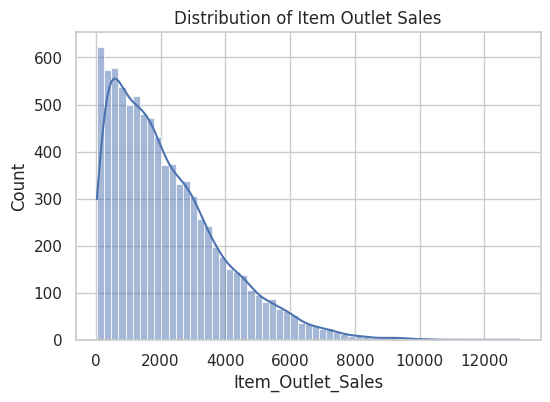

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(train_df["Item_Outlet_Sales"], kde=True)
plt.title("Distribution of Item Outlet Sales")
plt.show()

<Axes: >

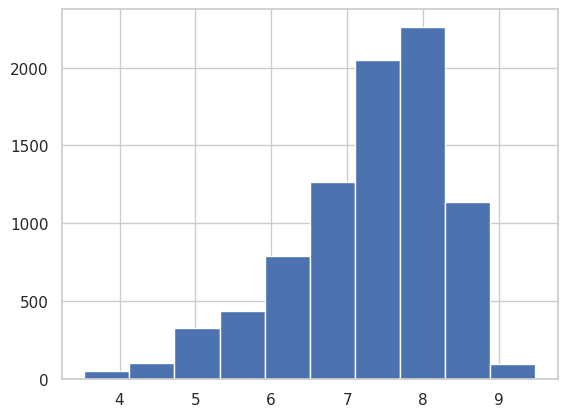

In [13]:
np.log1p(train_df["Item_Outlet_Sales"]).hist()


**Missing Values Analysis**

In [14]:
missing = train_df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

,0
Outlet_Size,0.282764
Item_Weight,0.171653


In [15]:
train_df.groupby("Item_Type")["Item_Weight"].median()

,Item_Weight
Item_Type,
Baking Goods,11.650
Breads,10.600
Breakfast,10.695
Canned,12.150
Dairy,13.350
Frozen Foods,12.850
Fruits and Vegetables,13.100
Hard Drinks,10.100
Health and Hygiene,12.150


**Handling Item_Weight**

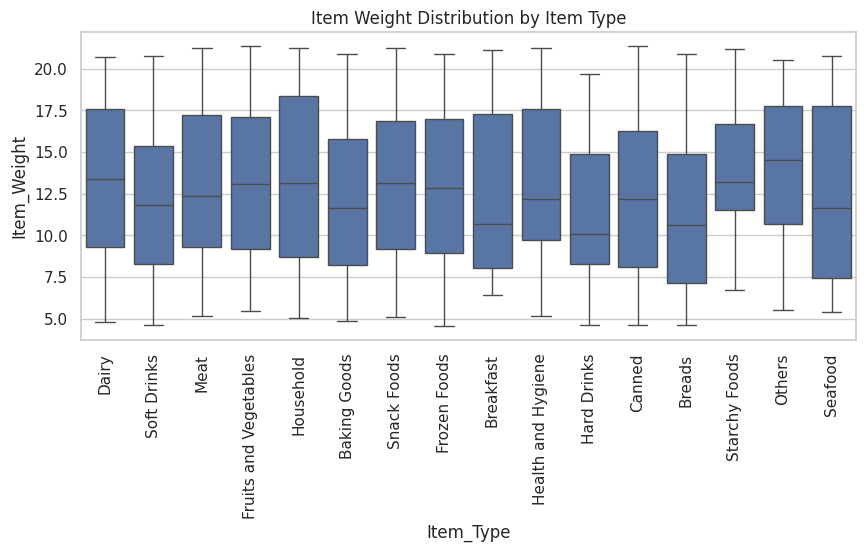

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(x="Item_Type", y="Item_Weight", data=train_df)
plt.xticks(rotation=90)
plt.title("Item Weight Distribution by Item Type")
plt.show()

In [17]:
item_weight_median = train_df.groupby("Item_Type")["Item_Weight"].median()

train_df["Item_Weight"] = train_df.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)

test_df["Item_Weight"] = test_df.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)


In [18]:
train_df.groupby("Outlet_Type")["Outlet_Size"].value_counts(dropna=False)

Outlet_Type        Outlet_Size
Grocery Store      NaN             555
                   Small           528
Supermarket Type1  Small          1860
                   NaN            1855
                   High            932
                   Medium          930
Supermarket Type2  Medium          928
Supermarket Type3  Medium          935
Name: count, dtype: int64

In [19]:
outlet_size_mode = (
    train_df.groupby("Outlet_Type")["Outlet_Size"]
    .agg(lambda x: x.mode()[0])
)

train_df["Outlet_Size"] = train_df.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)

test_df["Outlet_Size"] = test_df.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)


In [20]:
train_df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [21]:
mapping = {
    "low fat": "Low Fat",
    "lf": "Low Fat",
    "reg": "Regular",
    "regular" : "Regular"
}

train_df["Item_Fat_Content"] = (
    train_df["Item_Fat_Content"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(mapping)
)

test_df["Item_Fat_Content"] = (
    test_df["Item_Fat_Content"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(mapping)
)


In [22]:
(train_df["Item_Visibility"] == 0).mean()


np.float64(0.0617153584418632)

In [23]:
train_df.loc[train_df["Item_Visibility"] == 0, "Item_Visibility"] = np.nan
test_df.loc[test_df["Item_Visibility"] == 0, "Item_Visibility"] = np.nan

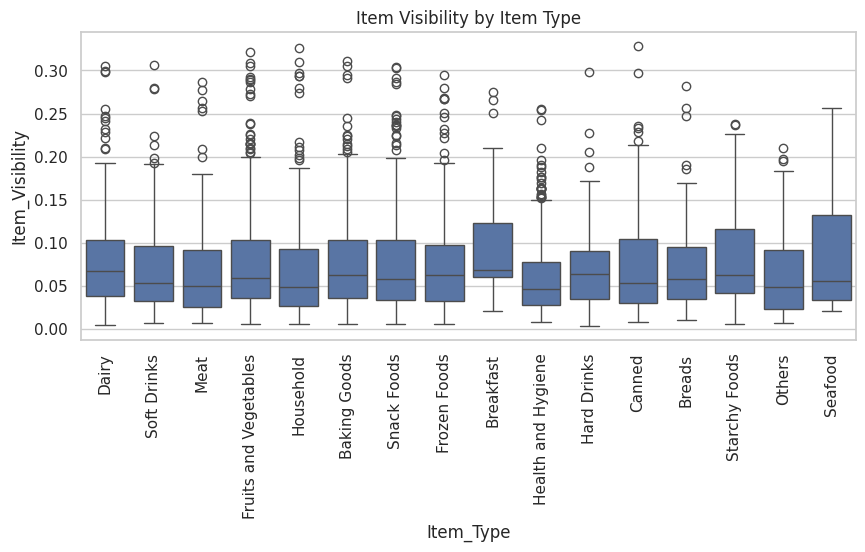

In [24]:
plt.figure(figsize=(10,4))
sns.boxplot(x="Item_Type", y="Item_Visibility", data=train_df)
plt.xticks(rotation=90)
plt.title("Item Visibility by Item Type")
plt.show()


In [25]:
visibility_median = train_df.groupby("Item_Type")["Item_Visibility"].median()

train_df["Item_Visibility"] = train_df.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)

test_df["Item_Visibility"] = test_df.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)


Feature Engineering


In [26]:
CURRENT_YEAR = 2013

train_df["Outlet_Age"] = CURRENT_YEAR - train_df["Outlet_Establishment_Year"]
test_df["Outlet_Age"] = CURRENT_YEAR - test_df["Outlet_Establishment_Year"]


Item MRP vs Sales

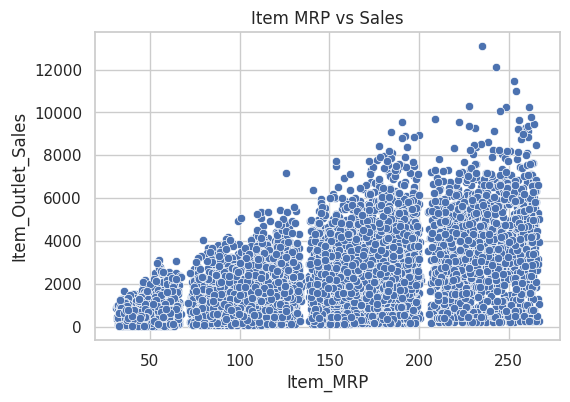

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Item_MRP", y="Item_Outlet_Sales", data=train_df)
plt.title("Item MRP vs Sales")
plt.show()


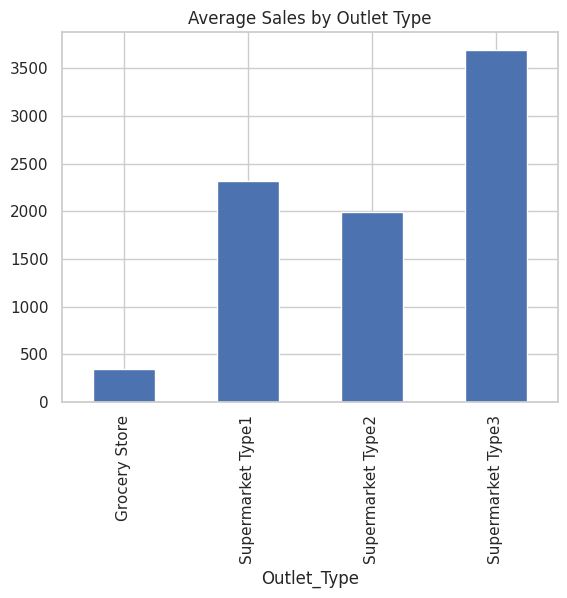

In [28]:
train_df.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().plot(kind="bar")
plt.title("Average Sales by Outlet Type")
plt.show()


In [29]:
train_df.isnull().sum()


,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [30]:
train_df.to_csv("/content/train_clean.csv", index=False)
test_df.to_csv("/content/test_clean.csv", index=False)

# Feature Engineering

Load Cleaned Data

In [31]:
clean_train = pd.read_csv('/content/train_clean.csv')
clean_test = pd.read_csv('/content/test_clean.csv')

In [32]:
print(clean_train.shape, clean_test.shape)

(8523, 13) (5681, 12)


In [33]:
clean_train.drop(columns=["Item_Identifier"], inplace=True)
clean_test.drop(columns=["Item_Identifier"], inplace=True)


In [34]:
clean_train.drop(columns=["Outlet_Identifier"], inplace=True)
clean_test.drop(columns=["Outlet_Identifier"], inplace=True)


In [35]:
clean_train["Item_Fat_Content"].value_counts(dropna=False)

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [36]:
fat_map = {"Low Fat": 1, "Regular": 0}

clean_train["Item_Fat_Content"] = clean_train["Item_Fat_Content"].replace(fat_map).astype(int)
clean_test["Item_Fat_Content"] = clean_test["Item_Fat_Content"].replace(fat_map).astype(int)


/tmp/ipython-input-2503265049.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_train["Item_Fat_Content"] = clean_train["Item_Fat_Content"].replace(fat_map).astype(int)
/tmp/ipython-input-2503265049.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_test["Item_Fat_Content"] = clean_test["Item_Fat_Content"].replace(fat_map).astype(int)


In [37]:
print(clean_train["Item_Fat_Content"].value_counts())
clean_train["Item_Fat_Content"].dtype

Item_Fat_Content
1    5517
0    3006
Name: count, dtype: int64


dtype('int64')

In [38]:
clean_train["Item_Fat_Content"] = clean_train["Item_Fat_Content"].astype(int)
clean_test["Item_Fat_Content"] = clean_test["Item_Fat_Content"].astype(int)


In [39]:
X = clean_train.drop("Item_Outlet_Sales", axis=1)
y = clean_train["Item_Outlet_Sales"]


In [40]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

categorical_features, numerical_features


(['Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
 ['Item_Weight',
  'Item_Fat_Content',
  'Item_Visibility',
  'Item_MRP',
  'Outlet_Establishment_Year',
  'Outlet_Age'])

Some categories may exist only in train or test

Ensures consistent feature space

In [41]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

test_encoded = pd.get_dummies(
    clean_test,
    columns=categorical_features,
    drop_first=True
)

# Align train & test
X_encoded, test_encoded = X_encoded.align(test_encoded, join="left", axis=1, fill_value=0)


Scale Numeric feature

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

test_scaled = test_encoded.copy()
test_scaled[numerical_features] = scaler.transform(test_encoded[numerical_features])


Save feature sets

In [43]:
X_encoded.to_csv("/content/X_unscaled.csv", index=False)
X_scaled.to_csv("/content/X_scaled.csv", index=False)
y.to_csv("/content/y.csv", index=False)
test_encoded.to_csv("/content/test_unscaled.csv", index=False)
test_scaled.to_csv("/content/test_scaled.csv", index=False)


In [44]:
print("Unscaled feature count:", X_encoded.shape[1])

Unscaled feature count: 28


In [45]:
X_encoded.columns.tolist()

['Item_Weight',
 'Item_Fat_Content',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Outlet_Age',
 'Item_Type_Breads',
 'Item_Type_Breakfast',
 'Item_Type_Canned',
 'Item_Type_Dairy',
 'Item_Type_Frozen Foods',
 'Item_Type_Fruits and Vegetables',
 'Item_Type_Hard Drinks',
 'Item_Type_Health and Hygiene',
 'Item_Type_Household',
 'Item_Type_Meat',
 'Item_Type_Others',
 'Item_Type_Seafood',
 'Item_Type_Snack Foods',
 'Item_Type_Soft Drinks',
 'Item_Type_Starchy Foods',
 'Outlet_Size_Medium',
 'Outlet_Size_Small',
 'Outlet_Location_Type_Tier 2',
 'Outlet_Location_Type_Tier 3',
 'Outlet_Type_Supermarket Type1',
 'Outlet_Type_Supermarket Type2',
 'Outlet_Type_Supermarket Type3']

In [46]:
X_encoded.drop(columns=["Outlet_Establishment_Year"], inplace=True)

# Modeling

In [47]:
y = clean_train["Item_Outlet_Sales"]
X = X_encoded


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


Baseline Linear Regression Model

In [50]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_rmse = evaluate_model(lr, X_train, y_train, X_val, y_val)

print("Linear Regression RMSE:", lr_rmse)


Linear Regression RMSE: 1070.0568751104777


Ridge Regression

In [51]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge_rmse = evaluate_model(ridge, X_train, y_train, X_val, y_val)

print("Ridge RMSE:", ridge_rmse)


Ridge RMSE: 1070.3568763738133


lasso Regression

In [52]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso_rmse = evaluate_model(lasso, X_train, y_train, X_val, y_val)

print("Lasso RMSE:", lasso_rmse)


Lasso RMSE: 1070.0645958710713


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.508e+09, tolerance: 2.017e+06
  model = cd_fast.enet_coordinate_descent(


Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_rmse = evaluate_model(rf, X_train, y_train, X_val, y_val)

print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 1092.8827738562204


Gradient Boosted Tree

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gbr_rmse = evaluate_model(gbr, X_train, y_train, X_val, y_val)

print("Gradient Boosting RMSE:", gbr_rmse)


Gradient Boosting RMSE: 1056.5930454435247


Compare

In [55]:
results = {
    "Linear Regression": lr_rmse,
    "Ridge": ridge_rmse,
    "Lasso": lasso_rmse,
    "Random Forest": rf_rmse,
    "Gradient Boosting": gbr_rmse
}

for model, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model}: {score}")


Gradient Boosting: 1056.5930454435247
Linear Regression: 1070.0568751104777
Lasso: 1070.0645958710713
Ridge: 1070.3568763738133
Random Forest: 1092.8827738562204


In [56]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )
    return -scores.mean()


In [57]:
print("GB CV RMSE:", cv_rmse(gbr, X, y))
print("RF CV RMSE:", cv_rmse(rf, X, y))
print("Linear CV RMSE:", cv_rmse(lr, X, y))


GB CV RMSE: 1101.0939647173104
RF CV RMSE: 1141.3097629256943
Linear CV RMSE: 1131.8571547344704


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

param_dist = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 3, 5, 10],
    "subsample": [0.8, 1.0]
}

gbr = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, y)

print("Best CV RMSE:", -random_search.best_score_)
print("Best Params:", random_search.best_params_)


Best CV RMSE: 1094.3030533011372
Best Params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.05}


In [162]:
visibility_mean = clean_train.groupby("Item_Type")["Item_Visibility"].transform("mean")
clean_train["Visibility_Ratio"] = clean_train["Item_Visibility"] / visibility_mean


In [164]:
# Compute mean visibility per Item_Type from TRAIN
visibility_mean_map = clean_train.groupby("Item_Type")["Item_Visibility"].mean()

# Map means to test
clean_test["Visibility_Ratio"] = (
    clean_test["Item_Visibility"] /
    clean_test["Item_Type"].map(visibility_mean_map)
)


In [165]:
clean_train.drop(columns=["Outlet_Establishment_Year"], inplace=True)
clean_test.drop(columns=["Outlet_Establishment_Year"], inplace=True)


In [166]:
y = clean_train["Item_Outlet_Sales"]
X_raw = clean_train.drop("Item_Outlet_Sales", axis=1)


In [167]:
X_encoded = pd.get_dummies(
    X_raw,
    drop_first=True
)

test_encoded = pd.get_dummies(
    clean_test,
    drop_first=True
)

# Align train/test
X_encoded, test_encoded = X_encoded.align(test_encoded, join="left", axis=1, fill_value=0)


In [168]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

gbr_tuned = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    gbr_tuned,
    X_encoded,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("New CV RMSE:", -scores.mean())


New CV RMSE: 1092.40609969065


In [59]:
model_1_GB = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_1_GB.fit(X_encoded, y)


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_leaf=10,
                          n_estimators=200, random_state=42, subsample=0.8)

In [62]:
predictions = model_1_GB.predict(test_encoded)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Outlet_Establishment_Year


In [169]:
!pip install xgboost


In [170]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

scores = cross_val_score(
    xgb,
    X_encoded,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("XGB CV RMSE:", -scores.mean())


XGB CV RMSE: 1110.248201193961
